# Deep Discounting Is Associated With Lower Cohort Quality

This notebook deepens the slide observation that customer count recovered while revenue per customer weakened. The analysis is intentionally descriptive: it does **not** present discounting as responsible for lower loyalty. Instead, it asks whether deeper first-order discounts are **associated with** weaker same-age customer quality signals.

**Data boundary:** this notebook uses only `EDA/outputs` files and recomputes the cohort drilldowns from those prepared EDA outputs. It does not read from `data/gold` or `data/silver`.

**Core question:** did the recent rise in deep discounting potentially attract or coincide with cohorts that look less loyal when measured at the same customer age?

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "EDA" / "outputs"
DATA_SOURCES = {
    "orders": OUTPUT_DIR / "orders.parquet",
    "customers": OUTPUT_DIR / "customers.parquet",
    "lines": OUTPUT_DIR / "lines.parquet",
    "annual_summary": OUTPUT_DIR / "02_orders_by_year.csv",
    "existing_discount_bins": OUTPUT_DIR / "05_discount_depth_bins.csv",
}

for name, path in DATA_SOURCES.items():
    assert path.exists(), f"Missing {name}: {path}"

source_text = "\n".join(str(p) for p in DATA_SOURCES.values()).lower()
for forbidden in [("data", "gold"), ("data", "silver")]:
    assert "/".join(forbidden) not in source_text

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

TEAL = "#16B886"
BLUE = "#1F77B4"
ORANGE = "#C76E00"
RED = "#D62728"
NAVY = "#23395B"
SLATE = "#667085"
GOLD = "#D9A441"
PURPLE = "#7A5CFA"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def display_table(df, formats=None, columns=None):
    """Display a readable table without requiring pandas Styler/jinja2."""
    out = df.copy()
    if columns is not None:
        out = out[columns]
    formats = formats or {}
    for col, fmt in formats.items():
        if col in out.columns:
            out[col] = out[col].map(lambda x: "" if pd.isna(x) else fmt.format(x))
    display(out)

print("Using only EDA/outputs sources:")
for name, path in DATA_SOURCES.items():
    print(f"- {name}: {path.relative_to(PROJECT_ROOT)}")

Using only EDA/outputs sources:
- orders: EDA/outputs/orders.parquet
- customers: EDA/outputs/customers.parquet
- lines: EDA/outputs/lines.parquet
- annual_summary: EDA/outputs/02_orders_by_year.csv
- existing_discount_bins: EDA/outputs/05_discount_depth_bins.csv


## 1. Load the EDA Outputs and Rebuild Cohort Features

The notebook rebuilds the core cohort table from order-level data. The key methodological choice is **same-age comparison**: a cohort is evaluated on behavior within 180 or 365 days of the first order, rather than by whatever revenue happened in a calendar year.

Discount depth is measured as:

`first_order_discount / (first_order_revenue + first_order_discount)`

This is an explainable proxy for the share of the first purchase that was funded by discounting. It is not a causal treatment variable.

In [2]:
orders = pd.read_parquet(DATA_SOURCES["orders"]).copy()
customers = pd.read_parquet(DATA_SOURCES["customers"]).copy()
lines = pd.read_parquet(DATA_SOURCES["lines"]).copy()
annual = pd.read_csv(DATA_SOURCES["annual_summary"])

orders["order_date"] = pd.to_datetime(orders["order_date"])
lines["order_date"] = pd.to_datetime(lines["order_date"])

for col in ["Price: Total", "Price: Total Discount", "Price: Total Shipping"]:
    orders[col] = pd.to_numeric(orders[col], errors="coerce").fillna(0)

orders = orders[orders["customer_id"].notna()].copy()
orders = orders.sort_values(["customer_id", "order_date", "order_id"])
orders["order_year"] = orders["order_date"].dt.year
orders["net_revenue_sgd"] = orders["Price: Total"].clip(lower=0)
orders["discount_sgd"] = orders["Price: Total Discount"].clip(lower=0)
orders["gross_before_discount_sgd"] = orders["net_revenue_sgd"] + orders["discount_sgd"]
orders["discount_depth"] = np.where(
    orders["gross_before_discount_sgd"] > 0,
    orders["discount_sgd"] / orders["gross_before_discount_sgd"],
    0,
).clip(0, 1)
orders["is_full_price_order"] = orders["discount_sgd"].le(0)

analysis_date = orders["order_date"].max().normalize()
print(f"Orders: {len(orders):,}")
print(f"Customers in orders: {orders['customer_id'].nunique():,}")
print(f"Analysis date inferred from max order date: {analysis_date.date()}")

Orders: 27,350
Customers in orders: 13,780
Analysis date inferred from max order date: 2026-03-31


In [3]:
def discount_band(depth):
    if pd.isna(depth) or depth <= 0:
        return "Full price"
    if depth <= 0.10:
        return "1-10%"
    if depth <= 0.20:
        return "11-20%"
    if depth <= 0.30:
        return "21-30%"
    return "31%+"

BAND_ORDER = ["Full price", "1-10%", "11-20%", "21-30%", "31%+"]

first_orders = (
    orders.sort_values(["customer_id", "order_date", "order_id"])
    .groupby("customer_id", as_index=False)
    .first()[[
        "customer_id", "order_id", "order_date", "channel", "store", "product_category",
        "net_revenue_sgd", "discount_sgd", "gross_before_discount_sgd", "discount_depth"
    ]]
    .rename(columns={
        "order_id": "first_order_id",
        "order_date": "first_order_date",
        "channel": "first_channel",
        "store": "first_store",
        "product_category": "first_product_category",
        "net_revenue_sgd": "first_order_revenue_sgd",
        "discount_sgd": "first_order_discount_sgd",
        "gross_before_discount_sgd": "first_order_gross_before_discount_sgd",
        "discount_depth": "first_discount_depth",
    })
)
first_orders["cohort_year"] = first_orders["first_order_date"].dt.year
first_orders["first_discount_band"] = pd.Categorical(
    first_orders["first_discount_depth"].apply(discount_band),
    categories=BAND_ORDER,
    ordered=True,
)
first_orders["first_discounted"] = first_orders["first_order_discount_sgd"].gt(0)
first_orders["eligible_365d"] = first_orders["first_order_date"].add(pd.Timedelta(days=365)).le(analysis_date)
first_orders["eligible_180d"] = first_orders["first_order_date"].add(pd.Timedelta(days=180)).le(analysis_date)

# Add order age relative to each customer's first purchase.
cohort_orders = orders.merge(
    first_orders[["customer_id", "first_order_date", "cohort_year"]],
    on="customer_id",
    how="left",
)
cohort_orders["days_since_first"] = (
    cohort_orders["order_date"] - cohort_orders["first_order_date"]
).dt.days
cohort_orders["is_repeat_order"] = cohort_orders["days_since_first"].gt(0)

# Same-age windows.
y1_orders = cohort_orders[cohort_orders["days_since_first"].between(0, 365, inclusive="both")].copy()
y180_orders = cohort_orders[cohort_orders["days_since_first"].between(0, 180, inclusive="both")].copy()
repeat_orders = cohort_orders[cohort_orders["is_repeat_order"]].copy()

customer_y1 = y1_orders.groupby("customer_id").agg(
    y1_revenue_sgd=("net_revenue_sgd", "sum"),
    y1_orders=("order_id", "count"),
    y1_discounted_order_share=("discount_sgd", lambda s: (s > 0).mean()),
).reset_index()
customer_y180 = y180_orders.groupby("customer_id").agg(
    y180_revenue_sgd=("net_revenue_sgd", "sum"),
    y180_orders=("order_id", "count"),
).reset_index()

repeat_flags = repeat_orders.groupby("customer_id").agg(
    repeat_180d=("days_since_first", lambda s: s.le(180).any()),
    repeat_365d=("days_since_first", lambda s: s.le(365).any()),
).reset_index()
full_price_repeat_flags = repeat_orders[repeat_orders["is_full_price_order"]].groupby("customer_id").agg(
    full_price_repeat_180d=("days_since_first", lambda s: s.le(180).any()),
    full_price_repeat_365d=("days_since_first", lambda s: s.le(365).any()),
).reset_index()

cohort_features = (
    first_orders
    .merge(customer_y1, on="customer_id", how="left")
    .merge(customer_y180, on="customer_id", how="left")
    .merge(repeat_flags, on="customer_id", how="left")
    .merge(full_price_repeat_flags, on="customer_id", how="left")
)
for col in ["y1_revenue_sgd", "y1_orders", "y1_discounted_order_share", "y180_revenue_sgd", "y180_orders"]:
    cohort_features[col] = cohort_features[col].fillna(0)
for col in ["repeat_180d", "repeat_365d", "full_price_repeat_180d", "full_price_repeat_365d"]:
    cohort_features[col] = cohort_features[col].fillna(False).astype(bool)

cohort_features = cohort_features[cohort_features["cohort_year"].between(2020, 2025)].copy()
print(f"Rebuilt cohort feature rows: {len(cohort_features):,}")
display(cohort_features.head())

Rebuilt cohort feature rows: 12,901


,customer_id,first_order_id,first_order_date,first_channel,first_store,first_product_category,first_order_revenue_sgd,first_order_discount_sgd,first_order_gross_before_discount_sgd,first_discount_depth,cohort_year,first_discount_band,first_discounted,eligible_365d,eligible_180d,y1_revenue_sgd,y1_orders,y1_discounted_order_share,y180_revenue_sgd,y180_orders,repeat_180d,repeat_365d,full_price_repeat_180d,full_price_repeat_365d
0,6327387259135,4992506265855,2022-06-29 00:00:00+08:00,Subscription,SG,Unknown,"1,693.120",0.000,"1,693.120",0.000,2022,Full price,False,True,True,"1,693.120",1,0.000,"1,693.120",1,False,False,False,False
1,6327388733695,4992632127743,2021-10-04 00:00:00+08:00,Subscription,SG,Unknown,222.200,0.000,222.200,0.000,2021,Full price,False,True,True,222.200,1,0.000,222.200,1,False,False,False,False
2,6327388799231,4992730300671,2021-02-05 00:00:00+08:00,Subscription,SG,Unknown,19.000,0.000,19.000,0.000,2021,Full price,False,True,True,93.070,3,0.000,19.000,1,False,True,False,True
3,6327389520127,4992722010367,2021-03-04 00:00:00+08:00,Subscription,SG,Unknown,29.000,0.000,29.000,0.000,2021,Full price,False,True,True,29.000,1,0.000,29.000,1,False,False,False,False
4,6327390699775,4992793739519,2020-08-18 00:00:00+08:00,Subscription,SG,Unknown,139.900,0.000,139.900,0.000,2020,Full price,False,True,True,492.980,2,0.000,492.980,2,True,True,True,True


## 2. Slide Context: More Customers, Less Revenue Per Customer, Larger Discount Burden

The slide's tension is visible in the annual data: customer volume recovered, but revenue per customer did not. At the same time, discounts became a much larger part of the commercial equation.

In [4]:
annual_ctx = annual[annual["year"].between(2020, 2025)].copy()
annual_ctx["revenue_per_customer_sgd"] = annual_ctx["revenue_sgd"] / annual_ctx["customers"]
annual_ctx["discounts_as_pct_gross"] = annual_ctx["disc_amt"] / (annual_ctx["revenue_sgd"] + annual_ctx["disc_amt"]).replace(0, np.nan)
annual_ctx["pct_orders_discounted"] = annual_ctx["disc_pct_orders"]

summary_cols = [
    "year", "orders", "customers", "revenue_sgd", "disc_amt",
    "revenue_per_customer_sgd", "pct_orders_discounted", "discounts_as_pct_gross"
]
display_table(
    annual_ctx[summary_cols],
    {
        "orders": "{:,.0f}", "customers": "{:,.0f}", "revenue_sgd": "S${:,.0f}",
        "disc_amt": "S${:,.0f}", "revenue_per_customer_sgd": "S${:,.0f}",
        "pct_orders_discounted": "{:.1%}", "discounts_as_pct_gross": "{:.1%}",
    },
)

base_2021 = annual_ctx.loc[annual_ctx["year"].eq(2021)].iloc[0]
latest_2025 = annual_ctx.loc[annual_ctx["year"].eq(2025)].iloc[0]
customer_change = latest_2025["customers"] / base_2021["customers"] - 1
rpc_change = latest_2025["revenue_per_customer_sgd"] / base_2021["revenue_per_customer_sgd"] - 1
disc_change_pp = latest_2025["discounts_as_pct_gross"] - base_2021["discounts_as_pct_gross"]

display(Markdown(
    f"**Read:** from 2021 to 2025, customers changed by {customer_change:+.1%}, "
    f"but revenue per customer changed by {rpc_change:+.1%}. "
    f"Discounts moved from {base_2021['discounts_as_pct_gross']:.1%} to "
    f"{latest_2025['discounts_as_pct_gross']:.1%} of gross-before-discount revenue. "
    "That pattern is consistent with more acquisition activity producing a less valuable average buyer, not necessarily a more loyal customer base."
))

,year,orders,customers,revenue_sgd,disc_amt,revenue_per_customer_sgd,pct_orders_discounted,discounts_as_pct_gross
1,2020,"2,847","1,696","S$456,952",S$0,S$269,0.0%,0.0%
2,2021,"6,259","3,815","S$847,930",S$0,S$222,0.0%,0.0%
3,2022,"3,710","2,299","S$747,587","S$30,073",S$325,15.2%,3.9%
4,2023,"2,253","1,399","S$182,038","S$32,419",S$130,59.3%,15.1%
5,2024,"4,261","2,621","S$284,971","S$127,408",S$109,69.2%,30.9%
6,2025,"6,407","4,107","S$409,152","S$222,033",S$100,49.6%,35.2%


**Read:** from 2021 to 2025, customers changed by +7.7%, but revenue per customer changed by -55.2%. Discounts moved from 0.0% to 35.2% of gross-before-discount revenue. That pattern is consistent with more acquisition activity producing a less valuable average buyer, not necessarily a more loyal customer base.

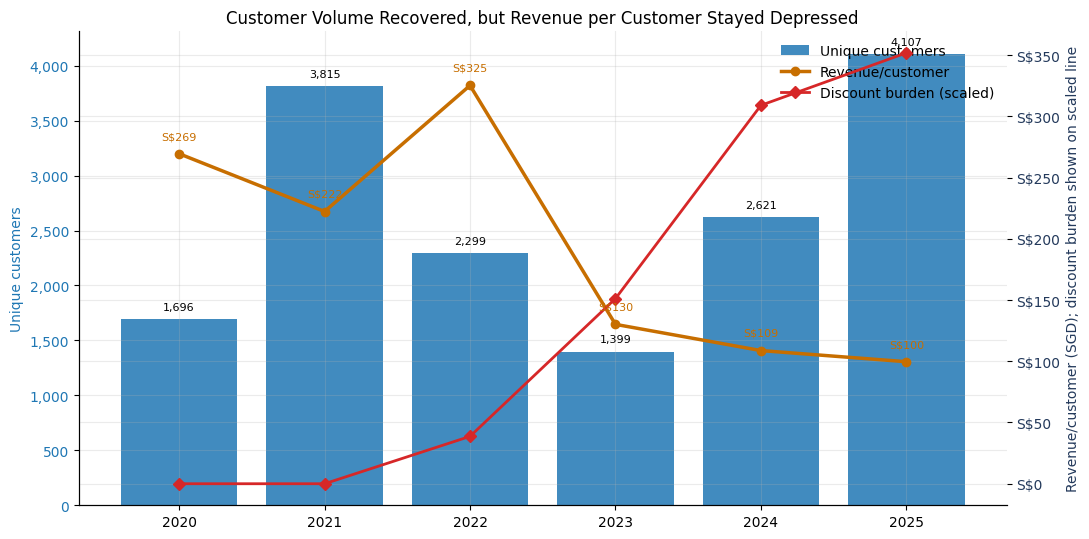

In [5]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(annual_ctx))
years = annual_ctx["year"].astype(str).tolist()

bars = ax1.bar(x, annual_ctx["customers"], color=BLUE, alpha=0.85, label="Unique customers")
ax1.set_ylabel("Unique customers", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(x, annual_ctx["revenue_per_customer_sgd"], color=ORANGE, marker="o", linewidth=2.5, label="Revenue/customer")
ax2.plot(x, annual_ctx["discounts_as_pct_gross"] * 1000, color=RED, marker="D", linewidth=2, label="Discount burden (scaled)")
ax2.set_ylabel("Revenue/customer (SGD); discount burden shown on scaled line", color=NAVY)
ax2.tick_params(axis="y", labelcolor=NAVY)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"S${v:,.0f}"))

for i, row in annual_ctx.iterrows():
    xi = list(annual_ctx.index).index(i)
    ax1.text(xi, row["customers"] + annual_ctx["customers"].max()*0.02, f"{row['customers']:,.0f}", ha="center", fontsize=8)
    ax2.text(xi, row["revenue_per_customer_sgd"] + 12, f"S${row['revenue_per_customer_sgd']:.0f}", ha="center", fontsize=8, color=ORANGE)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right", frameon=False)
ax1.set_title("Customer Volume Recovered, but Revenue per Customer Stayed Depressed")
fig.tight_layout()
plt.show()

## 3. Same-Age Cohort Quality

Calendar-year revenue mixes new and old customers together. The more careful view is to compare customers at the same age after acquisition.

Primary mature window: **2020-2024 cohorts**. The 2025 cohort is shown separately because many 2025 customers had not yet had a full 365-day observation window by the analysis date.

In [6]:
def summarize_cohort(df):
    return pd.Series({
        "acquired_customers": len(df),
        "eligible_365d": int(df["eligible_365d"].sum()),
        "pct_first_order_discounted": df["first_discounted"].mean(),
        "avg_first_discount_depth": df["first_discount_depth"].mean(),
        "avg_first_order_revenue_sgd": df["first_order_revenue_sgd"].mean(),
        "median_first_order_revenue_sgd": df["first_order_revenue_sgd"].median(),
        "repeat_365d": df.loc[df["eligible_365d"], "repeat_365d"].mean(),
        "full_price_repeat_365d": df.loc[df["eligible_365d"], "full_price_repeat_365d"].mean(),
        "avg_y1_revenue_sgd": df.loc[df["eligible_365d"], "y1_revenue_sgd"].mean(),
        "avg_y1_orders": df.loc[df["eligible_365d"], "y1_orders"].mean(),
    })

cohort_summary = cohort_features.groupby("cohort_year").apply(summarize_cohort).reset_index()
for c in ["acquired_customers", "eligible_365d"]:
    cohort_summary[c] = cohort_summary[c].astype(int)

display_table(
    cohort_summary,
    {
        "acquired_customers": "{:,.0f}", "eligible_365d": "{:,.0f}",
        "pct_first_order_discounted": "{:.1%}", "avg_first_discount_depth": "{:.1%}",
        "avg_first_order_revenue_sgd": "S${:,.0f}", "median_first_order_revenue_sgd": "S${:,.0f}",
        "repeat_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "avg_y1_revenue_sgd": "S${:,.0f}", "avg_y1_orders": "{:.2f}",
    },
)

mature = cohort_summary[cohort_summary["cohort_year"].between(2020, 2024)].copy()
display(Markdown(
    "**Read:** the 2024 cohort had the highest first-order discount exposure in the mature window, "
    f"with {mature.loc[mature['cohort_year'].eq(2024), 'pct_first_order_discounted'].iloc[0]:.1%} of acquired customers discounted on the first order. "
    "Its year-1 revenue/customer and full-price repeat rate were far below the earlier non-discounted cohorts."
))

,cohort_year,acquired_customers,eligible_365d,pct_first_order_discounted,avg_first_discount_depth,avg_first_order_revenue_sgd,median_first_order_revenue_sgd,repeat_365d,full_price_repeat_365d,avg_y1_revenue_sgd,avg_y1_orders
0,2020,"1,695","1,695",0.0%,0.0%,S$124,S$60,37.9%,37.9%,S$334,1.97
1,2021,"3,321","3,321",0.0%,0.0%,S$97,S$37,28.1%,27.9%,S$212,1.73
2,2022,"1,477","1,477",13.7%,3.7%,S$137,S$54,26.1%,19.1%,S$241,1.61
3,2023,874,874,61.0%,10.8%,S$66,S$57,25.7%,17.5%,S$107,1.62
4,2024,"2,015","2,015",81.5%,28.3%,S$59,S$55,28.1%,12.9%,S$99,1.62
5,2025,"3,519",260,61.6%,28.3%,S$58,S$37,23.8%,14.2%,S$293,3.98


**Read:** the 2024 cohort had the highest first-order discount exposure in the mature window, with 81.5% of acquired customers discounted on the first order. Its year-1 revenue/customer and full-price repeat rate were far below the earlier non-discounted cohorts.

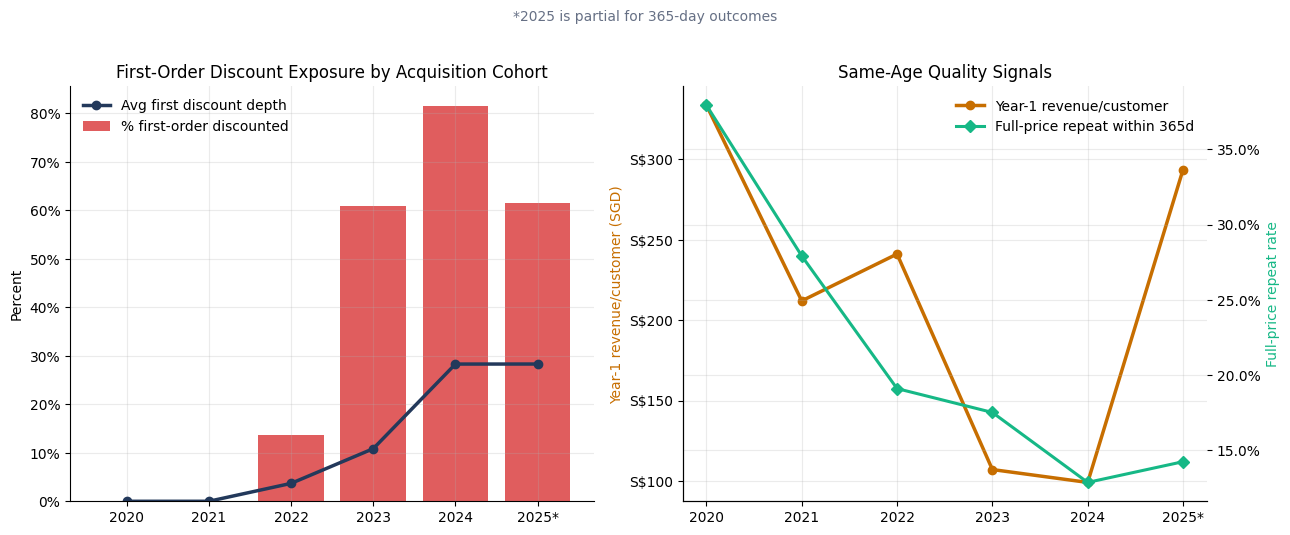

In [7]:
plot_df = cohort_summary[cohort_summary["cohort_year"].between(2020, 2025)].copy()
plot_df["label"] = plot_df["cohort_year"].astype(str) + np.where(plot_df["cohort_year"].eq(2025), "*", "")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
ax.bar(plot_df["label"], plot_df["pct_first_order_discounted"] * 100, color=RED, alpha=0.75, label="% first-order discounted")
ax.plot(plot_df["label"], plot_df["avg_first_discount_depth"] * 100, color=NAVY, marker="o", linewidth=2.5, label="Avg first discount depth")
ax.set_ylabel("Percent")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("First-Order Discount Exposure by Acquisition Cohort")
ax.legend(frameon=False)

ax = axes[1]
ax.plot(plot_df["label"], plot_df["avg_y1_revenue_sgd"], color=ORANGE, marker="o", linewidth=2.5, label="Year-1 revenue/customer")
ax2 = ax.twinx()
ax2.plot(plot_df["label"], plot_df["full_price_repeat_365d"] * 100, color=TEAL, marker="D", linewidth=2.2, label="Full-price repeat within 365d")
ax.set_ylabel("Year-1 revenue/customer (SGD)", color=ORANGE)
ax2.set_ylabel("Full-price repeat rate", color=TEAL)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Same-Age Quality Signals")
handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles + handles2, labels + labels2, frameon=False, loc="upper right")

fig.suptitle("*2025 is partial for 365-day outcomes", y=1.02, fontsize=10, color=SLATE)
fig.tight_layout()
plt.show()

## 4. Discount-Band Drilldown: Not All Acquired Customers Behave Alike

The most relevant comparison is not “discounted vs not discounted” across all years, because older cohorts have had more time and came from different channel/product mixes. The next view compares first-order discount bands **within acquisition cohorts**.

In [8]:
eligible = cohort_features[cohort_features["eligible_365d"]].copy()
main_eligible = eligible[eligible["cohort_year"].between(2020, 2024)].copy()

band_quality = (
    main_eligible.groupby(["cohort_year", "first_discount_band"], observed=True)
    .agg(
        customers=("customer_id", "count"),
        repeat_365d=("repeat_365d", "mean"),
        full_price_repeat_365d=("full_price_repeat_365d", "mean"),
        avg_y1_revenue_sgd=("y1_revenue_sgd", "mean"),
        median_y1_revenue_sgd=("y1_revenue_sgd", "median"),
        avg_first_order_revenue_sgd=("first_order_revenue_sgd", "mean"),
        avg_first_discount_depth=("first_discount_depth", "mean"),
    )
    .reset_index()
)

recent_band_quality = band_quality[band_quality["cohort_year"].isin([2023, 2024])].copy()
display_table(
    recent_band_quality,
    {
        "customers": "{:,.0f}", "repeat_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "avg_y1_revenue_sgd": "S${:,.0f}", "median_y1_revenue_sgd": "S${:,.0f}",
        "avg_first_order_revenue_sgd": "S${:,.0f}", "avg_first_discount_depth": "{:.1%}",
    },
)

cohort_2024 = recent_band_quality[recent_band_quality["cohort_year"].eq(2024)].set_index("first_discount_band")
if {"Full price", "31%+"}.issubset(set(cohort_2024.index.astype(str))):
    fp = cohort_2024.loc["Full price"]
    deep = cohort_2024.loc["31%+"]
    display(Markdown(
        f"**2024 read:** customers acquired at 31%+ first-order discount had {deep['repeat_365d']:.1%} 365-day repeat and "
        f"{deep['full_price_repeat_365d']:.1%} full-price repeat, versus {fp['repeat_365d']:.1%} and "
        f"{fp['full_price_repeat_365d']:.1%} for full-price first orders. This is an association, not a causal estimate."
    ))

,cohort_year,first_discount_band,customers,repeat_365d,full_price_repeat_365d,avg_y1_revenue_sgd,median_y1_revenue_sgd,avg_first_order_revenue_sgd,avg_first_discount_depth
7,2023,Full price,341,35.5%,31.1%,S$106,S$62,S$54,0.0%
8,2023,1-10%,200,19.0%,9.0%,S$105,S$78,S$77,5.6%
9,2023,11-20%,184,17.9%,8.2%,S$101,S$71,S$71,15.5%
10,2023,21-30%,85,31.8%,14.1%,S$160,S$106,S$92,24.5%
11,2023,31%+,64,9.4%,3.1%,S$65,S$32,S$50,53.4%
12,2024,Full price,373,39.9%,30.8%,S$116,S$65,S$56,0.0%
13,2024,1-10%,284,27.1%,12.3%,S$137,S$103,S$91,5.7%
14,2024,11-20%,362,28.2%,9.4%,S$108,S$67,S$66,15.4%
15,2024,21-30%,381,28.3%,10.5%,S$108,S$79,S$65,27.2%
16,2024,31%+,615,21.3%,5.7%,S$61,S$37,S$40,64.2%


**2024 read:** customers acquired at 31%+ first-order discount had 21.3% 365-day repeat and 5.7% full-price repeat, versus 39.9% and 30.8% for full-price first orders. This is an association, not a causal estimate.

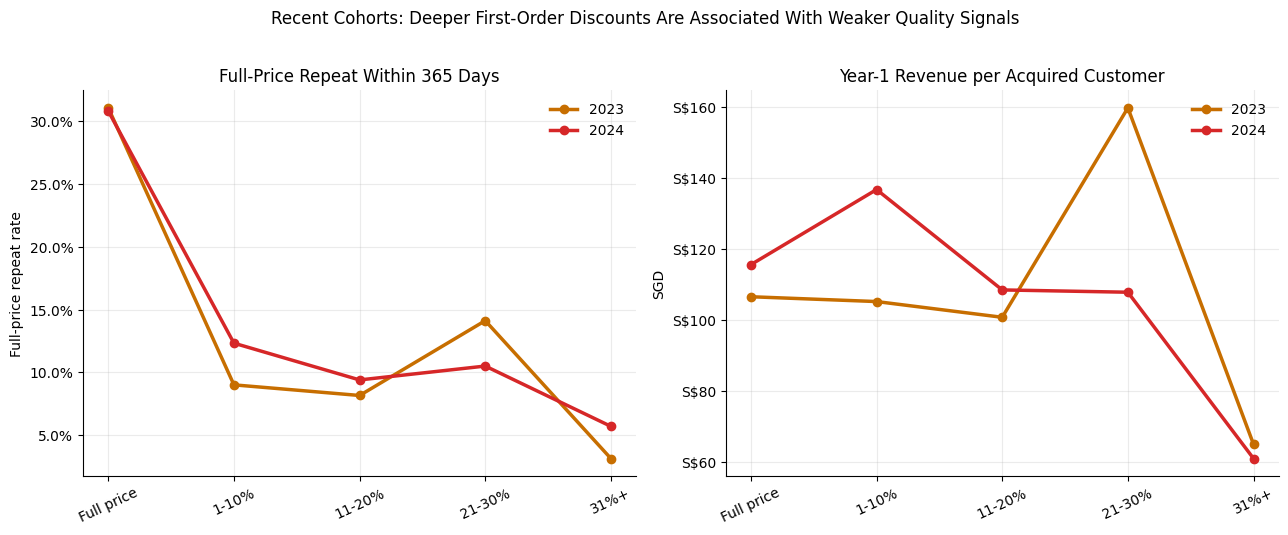

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True)
for yr, color in [(2023, ORANGE), (2024, RED)]:
    df = recent_band_quality[recent_band_quality["cohort_year"].eq(yr)].set_index("first_discount_band").reindex(BAND_ORDER)
    axes[0].plot(BAND_ORDER, df["full_price_repeat_365d"] * 100, marker="o", linewidth=2.5, color=color, label=str(yr))
    axes[1].plot(BAND_ORDER, df["avg_y1_revenue_sgd"], marker="o", linewidth=2.5, color=color, label=str(yr))

axes[0].set_title("Full-Price Repeat Within 365 Days")
axes[0].set_ylabel("Full-price repeat rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(frameon=False)

axes[1].set_title("Year-1 Revenue per Acquired Customer")
axes[1].set_ylabel("SGD")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
axes[1].legend(frameon=False)

for ax in axes:
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Recent Cohorts: Deeper First-Order Discounts Are Associated With Weaker Quality Signals", y=1.02)
fig.tight_layout()
plt.show()

## 5. Loyalty Ladder: Repeat Is Better When It Does Not Need Another Discount

A plain repeat purchase can still be promotion-led. To make the quality read stricter, this notebook uses **full-price repeat within 365 days** as a loyalty signal. This does not prove true loyalty, but it is a cleaner signal than “bought again at any price.”

,first_discount_band,customers,any_repeat_365d,full_price_repeat_365d,avg_y1_discounted_order_share,avg_y1_revenue_sgd,repeat_gap_pp
0,Full price,"7,005",31.2%,29.5%,1.6%,S$240,+1.7 pp
1,1-10%,553,24.1%,9.9%,95.2%,S$126,+14.1 pp
2,11-20%,572,24.5%,8.7%,95.5%,S$106,+15.7 pp
3,21-30%,506,28.3%,10.7%,94.4%,S$119,+17.6 pp
4,31%+,746,20.2%,5.4%,97.2%,S$65,+14.9 pp


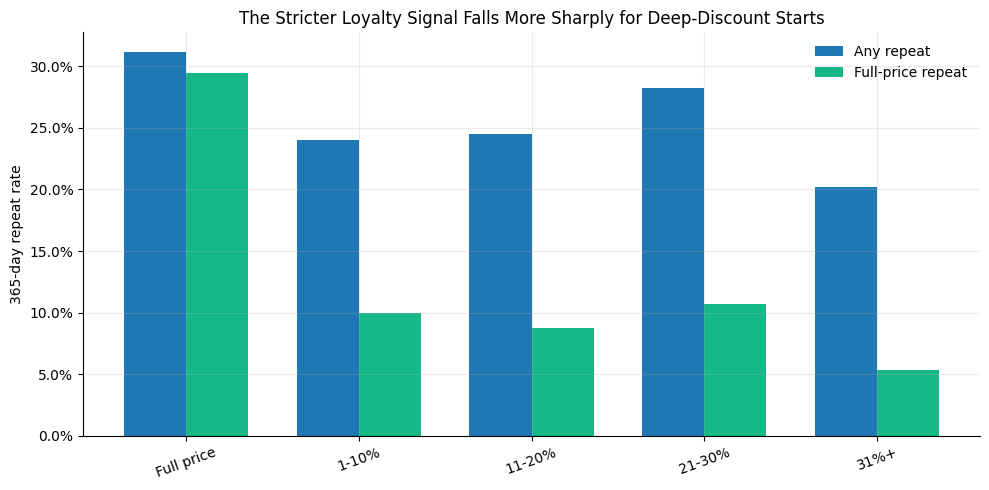

In [10]:
ladder = (
    main_eligible.groupby("first_discount_band", observed=True)
    .agg(
        customers=("customer_id", "count"),
        any_repeat_365d=("repeat_365d", "mean"),
        full_price_repeat_365d=("full_price_repeat_365d", "mean"),
        avg_y1_discounted_order_share=("y1_discounted_order_share", "mean"),
        avg_y1_revenue_sgd=("y1_revenue_sgd", "mean"),
    )
    .reindex(BAND_ORDER)
    .reset_index()
)
ladder["repeat_gap_pp"] = (ladder["any_repeat_365d"] - ladder["full_price_repeat_365d"]) * 100

display_table(
    ladder,
    {
        "customers": "{:,.0f}", "any_repeat_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "avg_y1_discounted_order_share": "{:.1%}", "avg_y1_revenue_sgd": "S${:,.0f}",
        "repeat_gap_pp": "{:+.1f} pp",
    },
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ladder))
w = 0.36
ax.bar(x - w/2, ladder["any_repeat_365d"] * 100, width=w, color=BLUE, label="Any repeat")
ax.bar(x + w/2, ladder["full_price_repeat_365d"] * 100, width=w, color=TEAL, label="Full-price repeat")
ax.set_xticks(x)
ax.set_xticklabels(ladder["first_discount_band"], rotation=20)
ax.set_ylabel("365-day repeat rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("The Stricter Loyalty Signal Falls More Sharply for Deep-Discount Starts")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Channel Robustness Check

If the pattern only appeared because the business shifted to a different channel, then discount depth would be a proxy for channel mix. The channel drilldown checks whether the discount-quality pattern is visible within major acquisition channels.

In [11]:
def simple_discount_group(band):
    if band == "Full price":
        return "Full price"
    if band in ["1-10%", "11-20%", "21-30%"]:
        return "1-30%"
    return "31%+"

recent_eligible = eligible[eligible["cohort_year"].isin([2023, 2024])].copy()
recent_eligible["discount_group"] = pd.Categorical(
    recent_eligible["first_discount_band"].astype(str).apply(simple_discount_group),
    categories=["Full price", "1-30%", "31%+"],
    ordered=True,
)

channel_counts = recent_eligible["first_channel"].value_counts()
major_channels = channel_counts[channel_counts >= 75].index.tolist()
channel_quality = (
    recent_eligible[recent_eligible["first_channel"].isin(major_channels)]
    .groupby(["first_channel", "discount_group"], observed=True)
    .agg(
        customers=("customer_id", "count"),
        repeat_365d=("repeat_365d", "mean"),
        full_price_repeat_365d=("full_price_repeat_365d", "mean"),
        avg_y1_revenue_sgd=("y1_revenue_sgd", "mean"),
        avg_first_discount_depth=("first_discount_depth", "mean"),
    )
    .reset_index()
)

display_table(
    channel_quality.sort_values(["first_channel", "discount_group"]),
    {
        "customers": "{:,.0f}", "repeat_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "avg_y1_revenue_sgd": "S${:,.0f}", "avg_first_discount_depth": "{:.1%}",
    },
)

pivot_channel = channel_quality.pivot(index="first_channel", columns="discount_group", values="avg_y1_revenue_sgd")
display_table(pivot_channel.reset_index(), {"Full price": "S${:,.0f}", "1-30%": "S${:,.0f}", "31%+": "S${:,.0f}"})

,first_channel,discount_group,customers,repeat_365d,full_price_repeat_365d,avg_y1_revenue_sgd,avg_first_discount_depth
0,Direct / Organic,Full price,191,22.0%,12.0%,S$71,0.0%
1,Direct / Organic,1-30%,529,27.2%,9.5%,S$110,14.7%
2,Direct / Organic,31%+,327,19.6%,4.3%,S$58,60.1%
3,Marketplace,Full price,184,16.8%,14.1%,S$79,0.0%
4,Marketplace,1-30%,326,6.1%,0.0%,S$59,12.8%
5,Marketplace,31%+,34,11.8%,0.0%,S$29,49.2%
6,Subscription,Full price,338,58.3%,50.9%,S$152,0.0%
7,Subscription,1-30%,641,34.5%,16.2%,S$148,18.2%
8,Subscription,31%+,318,21.7%,7.2%,S$68,67.8%


discount_group,first_channel,Full price,1-30%,31%+
0,Direct / Organic,S$71,S$110,S$58
1,Marketplace,S$79,S$59,S$29
2,Subscription,S$152,S$148,S$68


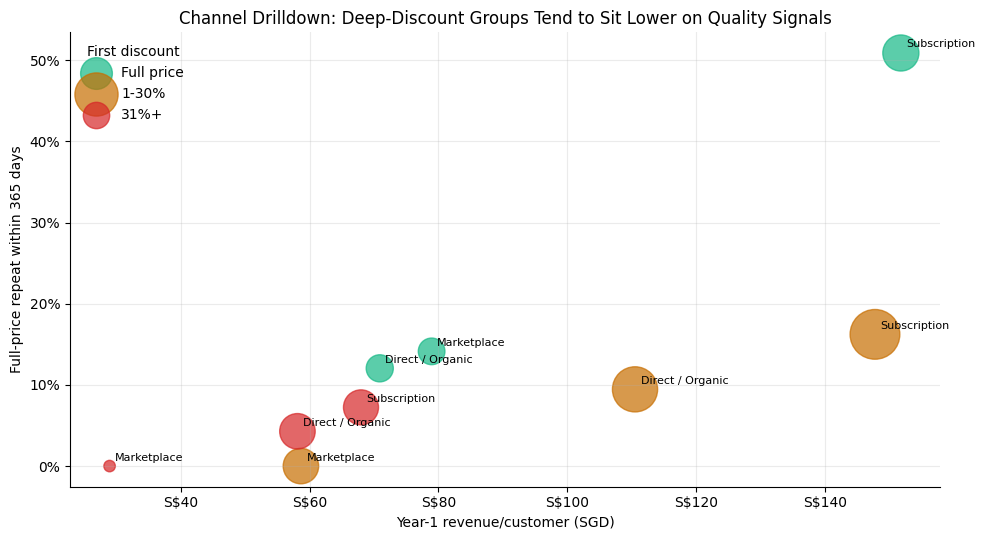

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_channel = channel_quality[channel_quality["customers"].ge(20)].copy()
for group, color in [("Full price", TEAL), ("1-30%", ORANGE), ("31%+", RED)]:
    df = plot_channel[plot_channel["discount_group"].eq(group)]
    ax.scatter(
        df["avg_y1_revenue_sgd"],
        df["full_price_repeat_365d"] * 100,
        s=np.maximum(df["customers"], 20) * 2,
        alpha=0.7,
        color=color,
        label=group,
    )
    for _, row in df.iterrows():
        ax.annotate(row["first_channel"], (row["avg_y1_revenue_sgd"], row["full_price_repeat_365d"] * 100),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("Year-1 revenue/customer (SGD)")
ax.set_ylabel("Full-price repeat within 365 days")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
ax.set_title("Channel Drilldown: Deep-Discount Groups Tend to Sit Lower on Quality Signals")
ax.legend(title="First discount", frameon=False)
fig.tight_layout()
plt.show()

## 7. Product Drilldown

The product view asks a similar robustness question: is the signal concentrated in only one product type, or does discount depth remain informative after splitting by first product category?

In [13]:
product_counts = recent_eligible["first_product_category"].value_counts()
major_products = product_counts[product_counts >= 75].index.tolist()
product_quality = (
    recent_eligible[recent_eligible["first_product_category"].isin(major_products)]
    .groupby(["first_product_category", "discount_group"], observed=True)
    .agg(
        customers=("customer_id", "count"),
        repeat_365d=("repeat_365d", "mean"),
        full_price_repeat_365d=("full_price_repeat_365d", "mean"),
        avg_y1_revenue_sgd=("y1_revenue_sgd", "mean"),
        avg_first_order_revenue_sgd=("first_order_revenue_sgd", "mean"),
    )
    .reset_index()
)

display_table(
    product_quality.sort_values(["first_product_category", "discount_group"]),
    {
        "customers": "{:,.0f}", "repeat_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "avg_y1_revenue_sgd": "S${:,.0f}", "avg_first_order_revenue_sgd": "S${:,.0f}",
    },
)

prod_pivot = product_quality.pivot(index="first_product_category", columns="discount_group", values="avg_y1_revenue_sgd")
display_table(prod_pivot.reset_index(), {"Full price": "S${:,.0f}", "1-30%": "S${:,.0f}", "31%+": "S${:,.0f}"})

,first_product_category,discount_group,customers,repeat_365d,full_price_repeat_365d,avg_y1_revenue_sgd,avg_first_order_revenue_sgd
0,Accessories,Full price,10,60.0%,50.0%,S$136,S$59
1,Accessories,1-30%,75,26.7%,14.7%,S$109,S$76
2,Accessories,31%+,31,16.1%,3.2%,S$63,S$27
3,Clear Protein,Full price,124,33.9%,28.2%,S$129,S$67
4,Clear Protein,1-30%,356,25.0%,9.8%,S$124,S$80
5,Clear Protein,31%+,159,20.8%,5.7%,S$62,S$42
6,Collagen Glow,Full price,63,50.8%,44.4%,S$103,S$47
7,Collagen Glow,1-30%,135,28.1%,11.1%,S$119,S$72
8,Collagen Glow,31%+,49,12.2%,4.1%,S$55,S$40
9,Lean Protein,Full price,31,45.2%,41.9%,S$143,S$61


discount_group,first_product_category,Full price,1-30%,31%+
0,Accessories,S$136,S$109,S$63
1,Clear Protein,S$129,S$124,S$62
2,Collagen Glow,S$103,S$119,S$55
3,Lean Protein,S$143,S$132,S$72
4,Other,S$113,S$108,S$69
5,Soy Protein,S$91,S$87,S$77
6,Unknown,S$80,S$131,S$26


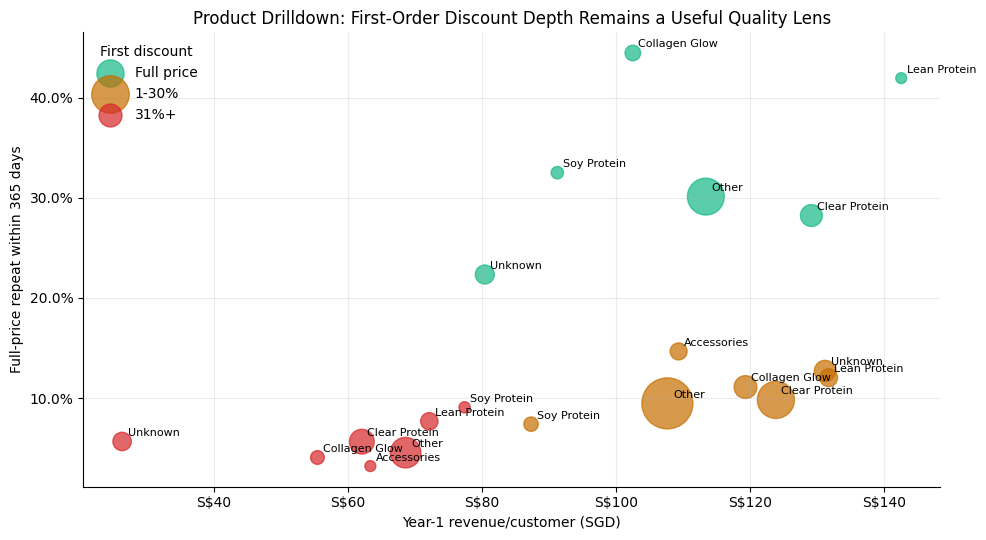

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_product = product_quality[product_quality["customers"].ge(20)].copy()
for group, color in [("Full price", TEAL), ("1-30%", ORANGE), ("31%+", RED)]:
    df = plot_product[plot_product["discount_group"].eq(group)]
    ax.scatter(
        df["avg_y1_revenue_sgd"],
        df["full_price_repeat_365d"] * 100,
        s=np.maximum(df["customers"], 20) * 2,
        alpha=0.7,
        color=color,
        label=group,
    )
    for _, row in df.iterrows():
        ax.annotate(row["first_product_category"], (row["avg_y1_revenue_sgd"], row["full_price_repeat_365d"] * 100),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("Year-1 revenue/customer (SGD)")
ax.set_ylabel("Full-price repeat within 365 days")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
ax.set_title("Product Drilldown: First-Order Discount Depth Remains a Useful Quality Lens")
ax.legend(title="First discount", frameon=False)
fig.tight_layout()
plt.show()

## 8. Explainable Decomposition: 2022 to 2024

This section uses simple descriptive accounting. It decomposes the change in average year-1 revenue/customer between 2022 and 2024 into:

- **Mix effect:** what would change if the 2024 segment mix were applied to 2022 segment quality?
- **Within-segment quality effect:** what remains after allowing each segment's observed quality to change?

This is **not** causal attribution. It is a way to see whether the observed decline is more aligned with discount-band mix than with channel mix.

In [15]:
def mix_decomposition(df, segment_col, metric_col, base_year=2022, compare_year=2024, min_customers=1):
    use = df[df["eligible_365d"] & df["cohort_year"].isin([base_year, compare_year])].copy()
    grouped = (
        use.groupby(["cohort_year", segment_col], observed=True)
        .agg(customers=("customer_id", "count"), quality=(metric_col, "mean"))
        .reset_index()
    )
    grouped = grouped[grouped["customers"].ge(min_customers)].copy()
    totals = grouped.groupby("cohort_year")["customers"].transform("sum")
    grouped["share"] = grouped["customers"] / totals

    wide = grouped.pivot(index=segment_col, columns="cohort_year", values=["share", "quality", "customers"])
    for top in ["share", "quality", "customers"]:
        for yr in [base_year, compare_year]:
            if (top, yr) not in wide.columns:
                wide[(top, yr)] = np.nan
    wide = wide.sort_index(axis=1)
    wide[("share", base_year)] = wide[("share", base_year)].fillna(0)
    wide[("share", compare_year)] = wide[("share", compare_year)].fillna(0)
    wide[("quality", base_year)] = wide[("quality", base_year)].fillna(wide[("quality", compare_year)])
    wide[("quality", compare_year)] = wide[("quality", compare_year)].fillna(wide[("quality", base_year)])

    s0 = wide[("share", base_year)]
    s1 = wide[("share", compare_year)]
    q0 = wide[("quality", base_year)]
    q1 = wide[("quality", compare_year)]

    base_avg = float((s0 * q0).sum())
    compare_avg = float((s1 * q1).sum())
    mix_effect = float(((s1 - s0) * q0).sum())
    quality_effect = float((s1 * (q1 - q0)).sum())
    actual_change = compare_avg - base_avg

    detail = pd.DataFrame({
        "segment": wide.index.astype(str),
        "base_share": s0.values,
        "compare_share": s1.values,
        "base_quality": q0.values,
        "compare_quality": q1.values,
        "share_change_pp": (s1.values - s0.values) * 100,
        "quality_change": q1.values - q0.values,
    })
    summary = pd.DataFrame([{
        "segment_col": segment_col,
        "metric": metric_col,
        "base_year": base_year,
        "compare_year": compare_year,
        "base_avg": base_avg,
        "compare_avg": compare_avg,
        "actual_change": actual_change,
        "mix_effect": mix_effect,
        "within_segment_quality_effect": quality_effect,
        "residual_check": actual_change - mix_effect - quality_effect,
    }])
    return summary, detail

disc_summary, disc_detail = mix_decomposition(cohort_features, "first_discount_band", "y1_revenue_sgd")
channel_summary, channel_detail = mix_decomposition(cohort_features, "first_channel", "y1_revenue_sgd")

combined_decomp = pd.concat([disc_summary, channel_summary], ignore_index=True)
display_table(
    combined_decomp,
    {
        "base_avg": "S${:,.0f}", "compare_avg": "S${:,.0f}", "actual_change": "S${:+,.0f}",
        "mix_effect": "S${:+,.0f}", "within_segment_quality_effect": "S${:+,.0f}",
        "residual_check": "S${:+,.2f}",
    },
)

display_table(
    disc_detail.sort_values("compare_share", ascending=False),
    {
        "base_share": "{:.1%}", "compare_share": "{:.1%}", "base_quality": "S${:,.0f}",
        "compare_quality": "S${:,.0f}", "share_change_pp": "{:+.1f} pp", "quality_change": "S${:+,.0f}",
    },
)

,segment_col,metric,base_year,compare_year,base_avg,compare_avg,actual_change,mix_effect,within_segment_quality_effect,residual_check
0,first_discount_band,y1_revenue_sgd,2022,2024,S$241,S$99,S$-142,S$-94,S$-48,S$+0.00
1,first_channel,y1_revenue_sgd,2022,2024,S$241,S$99,S$-142,S$-5,S$-137,S$-0.00


,segment,base_share,compare_share,base_quality,compare_quality,share_change_pp,quality_change
4,31%+,4.5%,30.5%,S$103,S$61,+26.0 pp,S$-42
3,21-30%,2.7%,18.9%,S$142,S$108,+16.2 pp,S$-34
0,Full price,86.3%,18.5%,S$259,S$116,-67.8 pp,S$-144
2,11-20%,1.8%,18.0%,S$115,S$108,+16.2 pp,S$-6
1,1-10%,4.7%,14.1%,S$146,S$137,+9.4 pp,S$-9


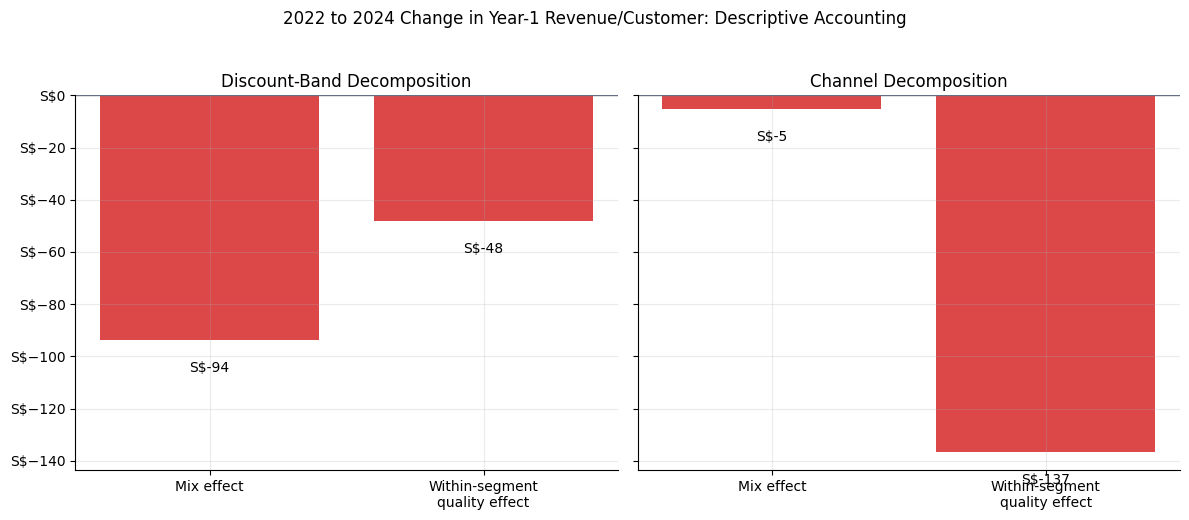

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, summary, title in [
    (axes[0], disc_summary.iloc[0], "Discount-Band Decomposition"),
    (axes[1], channel_summary.iloc[0], "Channel Decomposition"),
]:
    vals = [summary["mix_effect"], summary["within_segment_quality_effect"]]
    colors = [RED if v < 0 else TEAL for v in vals]
    ax.bar(["Mix effect", "Within-segment\nquality effect"], vals, color=colors, alpha=0.85)
    ax.axhline(0, color=SLATE, linewidth=1)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
    for i, v in enumerate(vals):
        ax.text(i, v + (5 if v >= 0 else -8), f"S${v:+,.0f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=10)
fig.suptitle("2022 to 2024 Change in Year-1 Revenue/Customer: Descriptive Accounting", y=1.03)
fig.tight_layout()
plt.show()

## 9. Synthesis

The evidence is consistent across several lenses:

1. Customer volume recovered, but revenue/customer remained materially lower while discount burden grew.
2. Same-age cohort quality weakened on stricter loyalty metrics such as full-price repeat within 365 days.
3. In recent cohorts, customers acquired through the deepest first-order discounts tend to show lower year-1 revenue/customer and lower full-price repeat.
4. The 2022-to-2024 decomposition suggests the shift toward deeper discount bands is more aligned with the year-1 revenue/customer decline than channel mix alone.

**Careful interpretation:** this does not prove deep discounts made customers less loyal. The safer reading is that heavy discounting may have changed the type of customer being acquired, or coincided with acquisition contexts that produced lower-quality cohorts.

## Caveats

- This is descriptive analysis only; no causal inference is attempted.
- 2025 is partial for 365-day outcomes and should be treated as directional.
- Marketplace and subscription behaviors are Shopify-visible only; purchases outside the synced Shopify view may be undercounted.
- Revenue is inherited from the EDA pipeline's SGD conversion assumptions, including fixed FX rates.
- First-order discount depth uses an explainable gross-before-discount proxy and may not capture every promotion mechanic perfectly.

In [17]:
# Final guardrail: prove the notebook's configured source paths avoid gold/silver datasets.
for name, path in DATA_SOURCES.items():
    lowered = str(path).lower()
    for forbidden in [("data", "gold"), ("data", "silver")]:
        assert "/".join(forbidden) not in lowered, path
print("Source-path guardrail passed: no forbidden prepared data paths configured.")

Source-path guardrail passed: no forbidden prepared data paths configured.
